# Fitting a multi-condition signaling network stored in AnnNet

A signaling analysis contains more than a pathway diagram. We also need to know which proteins were stimulated or inhibited, what was measured in each condition, which interactions were selected by the model, and what the model predicts.

In this tutorial, one AnnNet object keeps all of this information together. CORNETO provides the optimization method that fits the network.

We will use AnnNet to hold:

- a signed prior-knowledge network;
- nine perturbation experiments;
- the network selected by `CellNOptDAG`; and
- predicted protein and reaction activities for every condition.

The biological question is:

> Which routes through the candidate network are needed to explain the responses to TGFA, IGF1, and several kinase inhibitors?

The complete analysis can be saved as one `.annnet` file and explored later without rerunning the optimization.

## What data are used?

The protein names and candidate interactions come from a small part of the prior-knowledge network distributed with the [DREAM4 Predictive Signaling Network Challenge](https://pmc.ncbi.nlm.nih.gov/articles/PMC3465072/). The original challenge studied signaling responses in HepG2 cells after stimulation with ligands and treatment with kinase inhibitors.

To keep the model easy to understand, we use a small **synthetic perturbation experiment**. Stimuli and inhibitors are binary, while the responses are normalized values between `0` and `1`. We deliberately include experimental variation, so a Boolean model is not expected to reproduce every value exactly. The example uses real pathway names, but the measurements are illustrative and are not taken from the original DREAM dataset.

In [1]:
from pathlib import Path

import annnet as an
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from annnet.utils import plot as plot_annnet
from IPython.display import display

from corneto.methods.signaling import (
    CellNOptDAG,
    add_cellnopt_conditions,
    add_cellnopt_results,
    build_cellnopt_from_annnet,
    plot_cellnopt_fit,
    plot_cellnopt_model,
)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## 1. Create the signaling network in AnnNet

We begin with the biological network that will remain with us throughout the analysis. Each interaction has a sign: `+1` for activation and `−1` for inhibition.

The network contains two familiar branches:

- TGFA activates EGFR and can signal toward ERK1/2 and HSP27;
- IGF1 activates IGFR and can signal toward PI3K and AKT.

We also include several possible shortcuts and alternative routes. They are candidates that CORNETO may select if they help explain the experiments.

The interactions are placed in an AnnNet slice called `prior`. A slice is a named selection within a network. Later, another slice will identify the interactions selected by CellNOptDAG, while the original candidate network remains available.

In [2]:
display_name = {
    "tgfa": "TGFA", "egfr": "EGFR", "grb2": "GRB2", "shc": "SHC",
    "sos": "SOS", "ras": "RAS", "raf1": "RAF1", "mek12": "MEK1/2",
    "erk12": "ERK1/2", "prak": "PRAK", "hsp27": "HSP27", "pi3k": "PI3K",
    "pip3": "PIP3", "pdk1": "PDK1", "akt": "AKT", "igf1": "IGF1",
    "igfr": "IGFR", "irs1": "IRS1", "map3k1": "MAP3K1", "mkk4": "MKK4",
    "p38": "p38",
}

pkn_edges = [
    ("tgfa", 1, "egfr"), ("egfr", 1, "grb2"), ("egfr", 1, "shc"),
    ("shc", 1, "grb2"), ("grb2", 1, "sos"), ("sos", 1, "ras"),
    ("ras", 1, "raf1"), ("raf1", 1, "mek12"), ("mek12", 1, "erk12"),
    ("erk12", 1, "prak"), ("prak", 1, "hsp27"), ("egfr", 1, "pi3k"),
    ("ras", 1, "pi3k"), ("pi3k", 1, "pip3"), ("pip3", 1, "pdk1"),
    ("pdk1", 1, "akt"), ("igf1", 1, "igfr"), ("igfr", 1, "irs1"),
    ("irs1", 1, "pi3k"), ("igfr", 1, "shc"), ("ras", 1, "map3k1"),
    ("map3k1", 1, "mkk4"), ("mkk4", 1, "p38"), ("p38", 1, "prak"),
    ("akt", -1, "raf1"),
]

signaling = an.AnnNet(directed=True)
signaling.history.enable(True)
signaling.slices.add("prior", role="prior_knowledge")
signaling.add_vertices(sorted(display_name))

for protein, label in display_name.items():
    signaling.attrs.set_vertex_attrs(protein, label=label, entity_type="protein")

prior_edge_ids = []
for index, (source, sign, target) in enumerate(pkn_edges):
    edge_id = f"liverdream_{index:02d}"
    signaling.add_edges(
        source,
        target,
        edge_id=edge_id,
        slice="prior",
        directed=True,
        parallel="parallel",
    )
    signaling.attrs.set_edge_attrs(
        edge_id,
        interaction=sign,
        source_dataset="LiverDREAM",
    )
    prior_edge_ids.append(edge_id)

signaling.uns.update(
    {
        "title": "LiverDREAM-derived signaling example",
        "pkn_source": "DREAM4 Predictive Signaling Network Challenge",
        "data_scope": "Synthetic normalized signaling responses for software demonstration",
    }
)
signaling.history.snapshot("prior_loaded")

print(f"AnnNet contains {signaling.nv} proteins and {signaling.ne} signed interactions")

AnnNet contains 21 proteins and 25 signed interactions


### Inspect the candidate network

AnnNet draws the signed network directly. Arrowheads show activation, while a bar indicates inhibition.

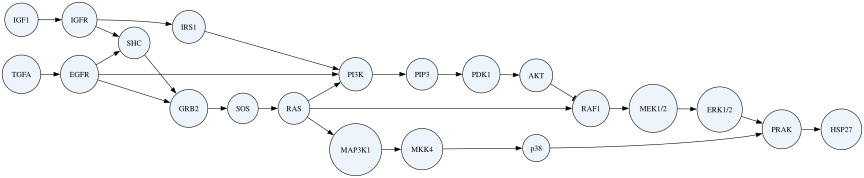

In [3]:
plot_annnet(
    signaling,
    backend="graphviz",
    layout="dot",
    vertex_label_key="label",
    use_weight_style=False,
    graph_attr={"rankdir": "LR", "size": "12,7"},
    node_attr={"shape": "ellipse", "style": "filled", "fillcolor": "#eef4fb"},
)

## 2. Add the perturbation experiments to AnnNet

Each condition records which ligands are present, which internal proteins are inhibited, and the measured activity of ERK1/2, AKT, and HSP27.

The conditions were chosen to distinguish alternative explanations:

- **TGFA with RAS inhibition** tests whether TGFA reaches PI3K through RAS or through the shorter candidate edge from EGFR to PI3K.
- **TGFA with MEK inhibition** blocks the ERK1/2–HSP27 branch while leaving the route to AKT available.
- **IGF1 alone** supports the route from IGFR through IRS1 to PI3K and AKT.
- **IGF1 with PI3K inhibition** tests whether the AKT response depends on PI3K, PIP3, and PDK1.

We store every condition as an AnnNet layer. Inputs, inhibitors, and measurements become attributes of the corresponding protein in that layer.

In [4]:
inputs = {
    "Basal": {"tgfa": 0, "igf1": 0},
    "TGFA": {"tgfa": 1, "igf1": 0},
    "TGFA + EGFRi": {"tgfa": 1, "igf1": 0},
    "TGFA + RASi": {"tgfa": 1, "igf1": 0},
    "TGFA + MEKi": {"tgfa": 1, "igf1": 0},
    "IGF1": {"tgfa": 0, "igf1": 1},
    "IGF1 + PI3Ki": {"tgfa": 0, "igf1": 1},
    "TGFA + IGF1": {"tgfa": 1, "igf1": 1},
    "Dual + MEKi": {"tgfa": 1, "igf1": 1},
}
measurements = {
    "Basal": {"erk12": 0.05, "akt": 0.08, "hsp27": 0.04},
    "TGFA": {"erk12": 0.90, "akt": 0.85, "hsp27": 0.80},
    "TGFA + EGFRi": {"erk12": 0.10, "akt": 0.15, "hsp27": 0.08},
    "TGFA + RASi": {"erk12": 0.15, "akt": 0.25, "hsp27": 0.12},
    "TGFA + MEKi": {"erk12": 0.20, "akt": 0.75, "hsp27": 0.18},
    "IGF1": {"erk12": 0.12, "akt": 0.88, "hsp27": 0.10},
    "IGF1 + PI3Ki": {"erk12": 0.10, "akt": 0.20, "hsp27": 0.10},
    "TGFA + IGF1": {"erk12": 0.92, "akt": 0.90, "hsp27": 0.85},
    "Dual + MEKi": {"erk12": 0.20, "akt": 0.82, "hsp27": 0.15},
}
inhibitors = {condition: {} for condition in inputs}
inhibitors["TGFA + EGFRi"] = {"egfr": 1}
inhibitors["TGFA + RASi"] = {"ras": 1}
inhibitors["TGFA + MEKi"] = {"mek12": 1}
inhibitors["IGF1 + PI3Ki"] = {"pi3k": 1}
inhibitors["Dual + MEKi"] = {"mek12": 1}

condition_layers = add_cellnopt_conditions(
    signaling,
    inputs=inputs,
    inhibitors=inhibitors,
    measurements=measurements,
)
signaling.history.snapshot("conditions_added")

print("Condition layers:", list(condition_layers))

Condition layers: ['Basal', 'TGFA', 'TGFA + EGFRi', 'TGFA + RASi', 'TGFA + MEKi', 'IGF1', 'IGF1 + PI3Ki', 'TGFA + IGF1', 'Dual + MEKi']


The AnnNet object now contains both the pathway and the experiment. The following small display helper reads selected protein attributes across its condition layers. It is independent of CellNOptDAG and is used only to make compact tables in this notebook.

In [5]:
def vertex_layer_table(network, layers, columns):
    """Return selected vertex-layer attributes as a pandas table."""
    rows = {}
    for condition, layer in layers.items():
        rows[condition] = {
            label: network.layers.get_vertex_layer_attrs(protein, layer).get(attribute, np.nan)
            for label, (protein, attribute) in columns.items()
        }
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis("condition")

In [6]:
experiment_columns = {
    "TGFA": ("tgfa", "input"),
    "IGF1": ("igf1", "input"),
    "EGFR inhibited": ("egfr", "inhibited"),
    "RAS inhibited": ("ras", "inhibited"),
    "MEK inhibited": ("mek12", "inhibited"),
    "PI3K inhibited": ("pi3k", "inhibited"),
    "ERK1/2 observed": ("erk12", "observed"),
    "AKT observed": ("akt", "observed"),
    "HSP27 observed": ("hsp27", "observed"),
}
experiment = vertex_layer_table(signaling, condition_layers, experiment_columns).fillna(0)
experiment

,TGFA,IGF1,EGFR inhibited,RAS inhibited,MEK inhibited,PI3K inhibited,ERK1/2 observed,AKT observed,HSP27 observed
condition,,,,,,,,,
Basal,0,0,0.0,0.0,0.0,0.0,0.05,0.08,0.04
TGFA,1,0,0.0,0.0,0.0,0.0,0.90,0.85,0.80
TGFA + EGFRi,1,0,1.0,0.0,0.0,0.0,0.10,0.15,0.08
TGFA + RASi,1,0,0.0,1.0,0.0,0.0,0.15,0.25,0.12
TGFA + MEKi,1,0,0.0,0.0,1.0,0.0,0.20,0.75,0.18
IGF1,0,1,0.0,0.0,0.0,0.0,0.12,0.88,0.10
IGF1 + PI3Ki,0,1,0.0,0.0,0.0,1.0,0.10,0.20,0.10
TGFA + IGF1,1,1,0.0,0.0,0.0,0.0,0.92,0.90,0.85
Dual + MEKi,1,1,0.0,0.0,1.0,0.0,0.20,0.82,0.15


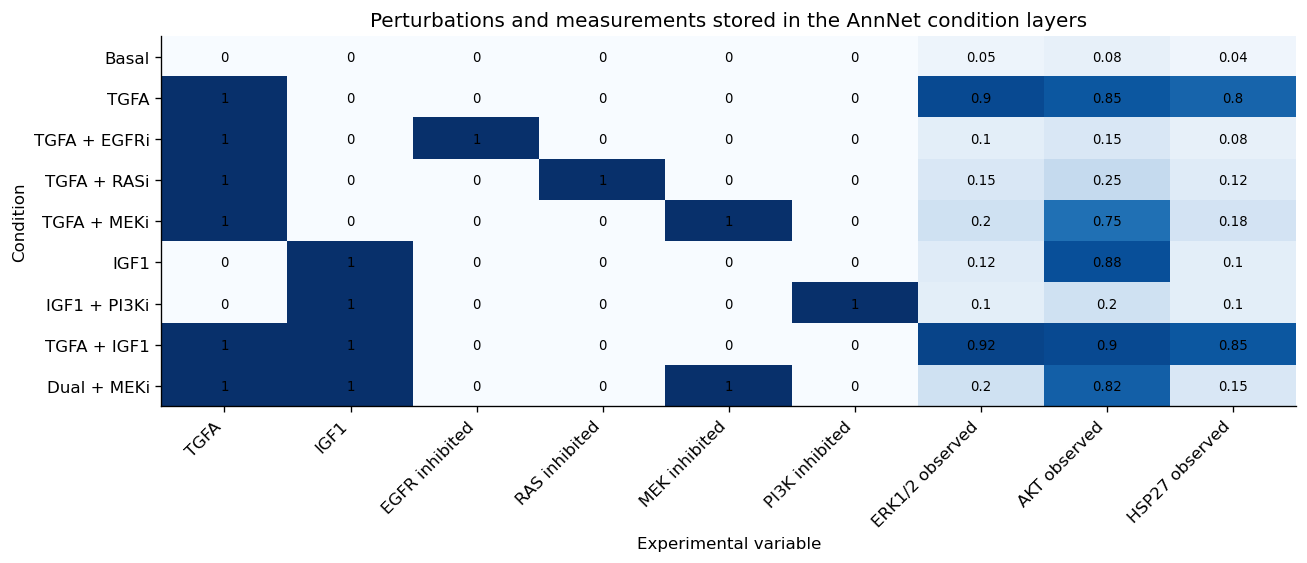

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.8))
matrix = experiment.to_numpy(dtype=float)
ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(experiment.shape[1]), experiment.columns, rotation=45, ha="right")
ax.set_yticks(range(experiment.shape[0]), experiment.index)
for row, column in np.ndindex(matrix.shape):
    ax.text(column, row, f"{matrix[row, column]:.2g}", ha="center", va="center", fontsize=8)
ax.set_title("Perturbations and measurements stored in the AnnNet condition layers")
ax.set_xlabel("Experimental variable")
ax.set_ylabel("Condition")
fig.tight_layout()
plt.show()

## 3. Fit the network with CORNETO

CORNETO reads the signed interactions and experimental conditions stored in AnnNet. CellNOptDAG searches for one set of reactions that explains all nine experiments. The selected reactions are shared across the experiment, although their activity can change from one condition to another.

CellNOptDAG predicts an inactive or active state for each protein, whereas the synthetic measurements vary continuously between `0` and `1`. It therefore searches for the binary response pattern that is closest to the observations rather than expecting a perfect numerical match.

We use a small value of `lambda_reg`. Reducing disagreement with the measurements is the first priority; when two models perform equally well, this value favors the model with fewer reactions.

In [8]:
method = CellNOptDAG(lambda_reg=1e-3)
problem = build_cellnopt_from_annnet(
    method,
    signaling,
    network_slice="prior",
    condition_layers=condition_layers,
)
solution = problem.solve(solver="SCIPY")

total_error = float(problem.objectives[0].value)
number_of_measurements = sum(len(values) for values in measurements.values())

print("Solver status:", solution.status)
print(f"Total absolute error: {total_error:.2f}")
print(f"Mean absolute error per measurement: {total_error / number_of_measurements:.2f}")

Solver status: optimal
Total absolute error: 3.70
Mean absolute error per measurement: 0.14


### Which routes were selected?

The fitted network keeps both stimulus-to-readout branches. It also keeps `RAS → PI3K`, which helps explain why TGFA produces a strong AKT response while RAS inhibition strongly reduces it.

The direct shortcut `EGFR → PI3K` is not selected. If it were present, PI3K could remain active after RAS inhibition, making the low AKT measurement harder to explain. The candidate routes from IGFR to ERK1/2 and from RAS through p38 to HSP27 are also unnecessary for this fit.

An interaction that is not selected should not be interpreted as biologically false. It was available in the candidate network, but this experiment can be explained without it.

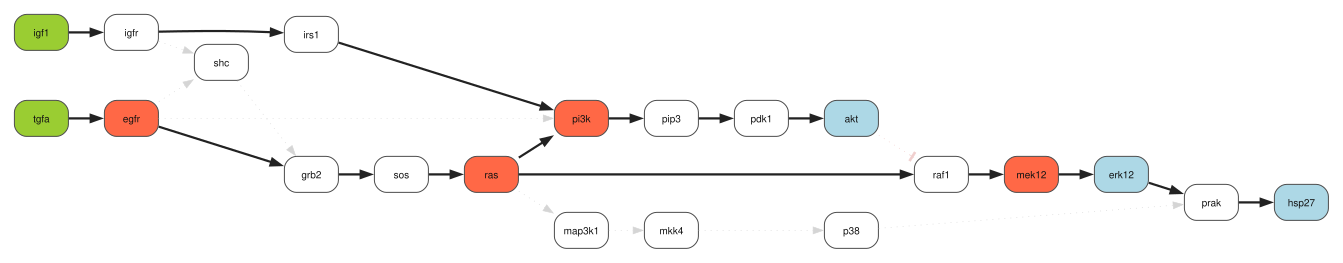

(<Figure size 1140x777.6 with 7 Axes>,
 array([<Axes: title={'center': 'Observed'}>,
        <Axes: title={'center': 'Model'}>,
        <Axes: title={'center': 'Absolute error'}>,
        <Axes: title={'center': 'Cues'}>], dtype=object))

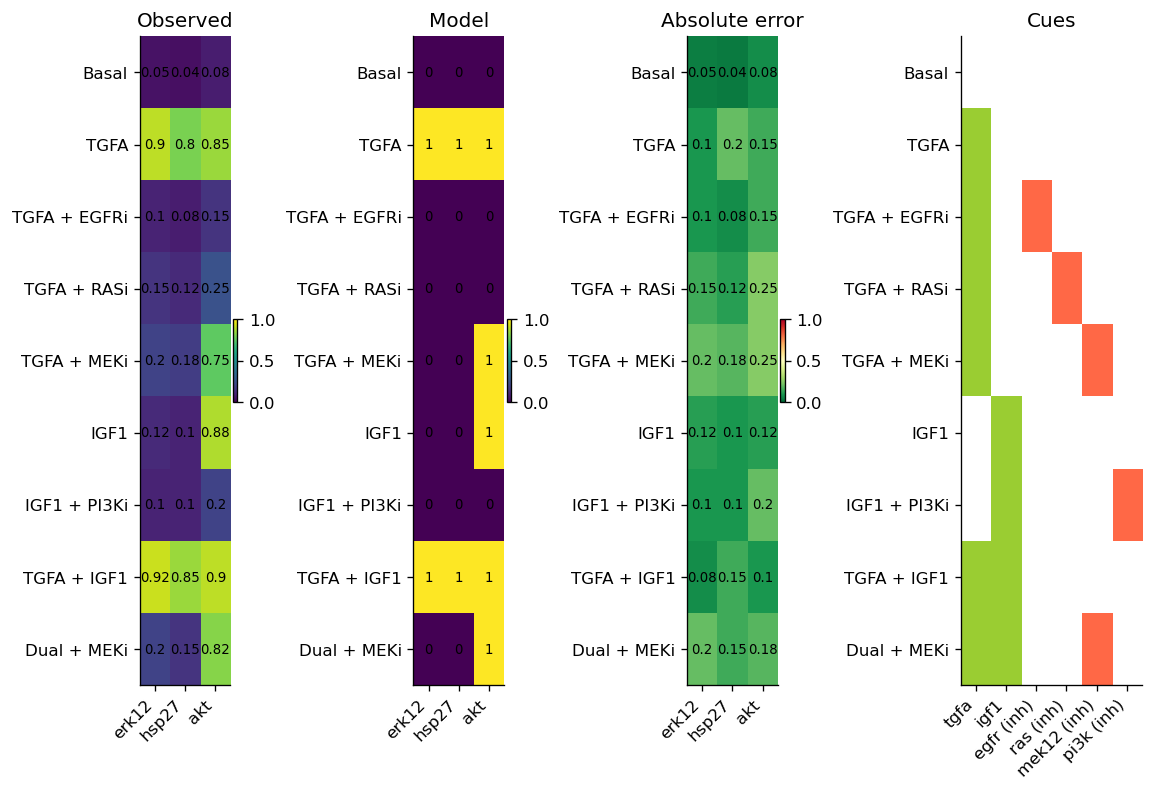

In [9]:
display(plot_cellnopt_model(method, show_unselected=True))
plot_cellnopt_fit(method, view="heatmap")

## 4. Add the fitted model to AnnNet

The optimization is complete, but the AnnNet object does not yet contain the inferred results. One signaling-specific CORNETO helper adds them:

- selected interactions are added to a slice called `cellnopt_selected`;
- predicted protein activities are added to each condition layer;
- selected reactions are marked as active or inactive in each condition; and
- fitting summaries are attached to the corresponding layers.

This helper works from CellNOptDAG variables and standard AnnNet attributes. It does not contain any LiverDREAM-specific proteins or conditions.

In [10]:
result_summary = add_cellnopt_results(
    signaling,
    method,
    problem,
    solution=solution,
)

pd.Series(
    {
        "selected reactions": result_summary["selected_reactions"],
        "selected prior interactions": result_summary["selected_prior_edges"],
        "condition-specific interaction records": result_summary["condition_edges"],
        "total absolute error": sum(result_summary["condition_errors"].values()),
    },
    name="stored CellNOptDAG results",
)

selected reactions                         16.0
selected prior interactions                16.0
condition-specific interaction records    144.0
total absolute error                        3.7
Name: stored CellNOptDAG results, dtype: float64

## 5. Explore the complete analysis in AnnNet

AnnNet now contains the candidate pathway, all experimental conditions, and the fitted results. We can answer biological questions from this object instead of combining solver variables with separate dictionaries.

### Which candidate interactions belong to the fitted model?

The `prior` and `cellnopt_selected` slices can be compared without losing either version of the pathway.

In [11]:
selected_prior_ids = set(prior_edge_ids) & set(signaling.slices.edges("cellnopt_selected"))
selected_rows = []
for edge_id in prior_edge_ids:
    if edge_id not in selected_prior_ids:
        continue
    sources, targets = signaling.get_edge(edge_id)
    source_node = next(iter(sources))
    target_node = next(iter(targets))
    source = source_node[0] if isinstance(source_node, tuple) else source_node
    target = target_node[0] if isinstance(target_node, tuple) else target_node
    sign = signaling.attrs.get_edge_attrs(edge_id)["interaction"]
    selected_rows.append(
        {
            "source": display_name[source],
            "sign": "activates" if sign == 1 else "inhibits",
            "target": display_name[target],
        }
    )

pd.DataFrame(selected_rows)

,source,sign,target
0,TGFA,activates,EGFR
1,EGFR,activates,GRB2
2,GRB2,activates,SOS
3,SOS,activates,RAS
4,RAS,activates,RAF1
5,RAF1,activates,MEK1/2
6,MEK1/2,activates,ERK1/2
7,ERK1/2,activates,PRAK
8,PRAK,activates,HSP27
9,RAS,activates,PI3K


### How does AKT respond across the experiment?

Observed and predicted AKT values are attributes of the same protein in different AnnNet layers. Reading them side by side shows both the perturbation response and the quality of the fit.

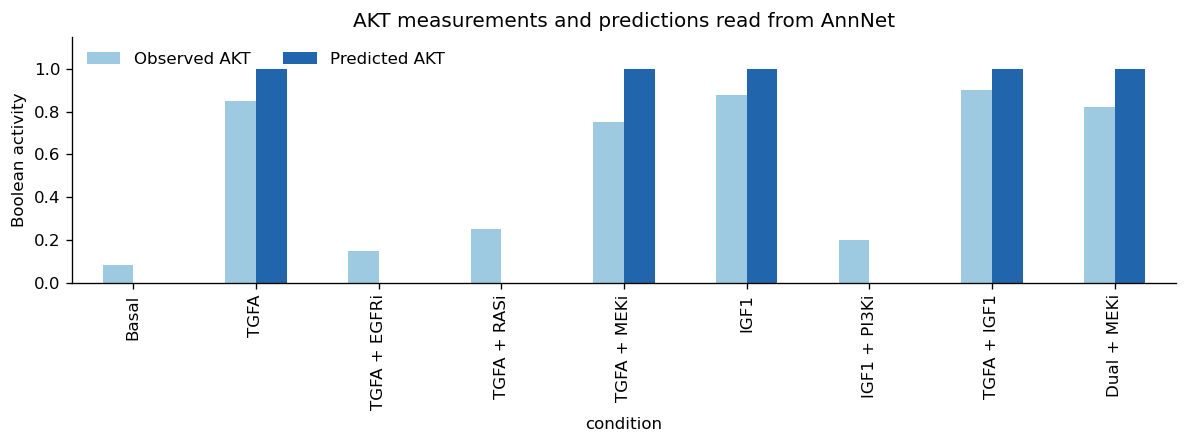

,Observed AKT,Predicted AKT
condition,,
Basal,0.08,0.0
TGFA,0.85,1.0
TGFA + EGFRi,0.15,0.0
TGFA + RASi,0.25,0.0
TGFA + MEKi,0.75,1.0
IGF1,0.88,1.0
IGF1 + PI3Ki,0.20,0.0
TGFA + IGF1,0.90,1.0
Dual + MEKi,0.82,1.0


In [12]:
akt_response = vertex_layer_table(
    signaling,
    condition_layers,
    {
        "Observed AKT": ("akt", "observed"),
        "Predicted AKT": ("akt", "predicted"),
    },
)

ax = akt_response.plot.bar(figsize=(10, 3.8), color=["#9ecae1", "#2166ac"])
ax.set_ylim(0, 1.15)
ax.set_ylabel("Boolean activity")
ax.set_title("AKT measurements and predictions read from AnnNet")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

akt_response

### Which reactions are active after a perturbation?

A reaction may belong to the fitted network but be inactive in a particular condition. The result layers preserve this distinction. For example, MEK inhibition removes activity from the ERK1/2 branch while leaving the route to AKT available.

In [13]:
def active_reactions_in(network, layer):
    """Return the distinct CellNOpt reactions active in one AnnNet layer."""
    reactions = set()
    for edge_id in network.layers.layer_edge_set(layer):
        attributes = network.attrs.get_edge_attrs(edge_id)
        if attributes.get("selected") and attributes.get("active"):
            reactions.add(attributes["reaction"])
    return sorted(reactions)


condition = "TGFA + MEKi"
pd.Series(active_reactions_in(signaling, condition_layers[condition]), name=condition)

0     egfr -> grb2
1      grb2 -> sos
2      pdk1 -> akt
3     pi3k -> pip3
4     pip3 -> pdk1
5    raf1 -> mek12
6      ras -> pi3k
7      ras -> raf1
8       sos -> ras
9     tgfa -> egfr
Name: TGFA + MEKi, dtype: object

## 6. Save the analysis and use it again

AnnNet's native format preserves the network, annotations, slices, condition layers, and fitting results. To demonstrate that the saved object is useful on its own, we reopen it and read the AKT result again without using the CORNETO model or its solver variables.

In [14]:
output_dir = Path("build")
output_dir.mkdir(exist_ok=True)
analysis_path = output_dir / "annnet-cellnopt-liverdream.annnet"

an.io.write(signaling, analysis_path, overwrite=True)
restored = an.io.read(analysis_path)

restored_akt = vertex_layer_table(
    restored,
    condition_layers,
    {
        "Observed AKT": ("akt", "observed"),
        "Predicted AKT": ("akt", "predicted"),
    },
)

assert restored_akt.equals(akt_response)
print("Saved analysis:", analysis_path)
restored_akt

Saved analysis: build/annnet-cellnopt-liverdream.annnet


,Observed AKT,Predicted AKT
condition,,
Basal,0.08,0.0
TGFA,0.85,1.0
TGFA + EGFRi,0.15,0.0
TGFA + RASi,0.25,0.0
TGFA + MEKi,0.75,1.0
IGF1,0.88,1.0
IGF1 + PI3Ki,0.20,0.0
TGFA + IGF1,0.90,1.0
Dual + MEKi,0.82,1.0


## What does AnnNet add?

AnnNet is the central graph object for the analysis. It provides a common place for the biological network, experimental data, and inferred results:

- **Proteins keep the same identity across conditions.** AKT is one protein with different measurements and predictions in different layers.
- **The candidate and fitted networks coexist.** Slices make them easy to compare without overwriting the original pathway.
- **Results remain connected to the biology.** Predictions and reaction activities are attached to the proteins, interactions, and conditions they describe.
- **The analysis can be exchanged and extended.** Another researcher can reopen the file, inspect a condition, or add annotations without reconstructing the work from notebook variables.
- **CORNETO methods can share the same graph object.** CORNETO supplies optimization methods; AnnNet supplies the annotated network that those methods read and enrich.

For a small one-off calculation, separate edge lists and tables may be sufficient. AnnNet becomes particularly useful when an analysis contains many conditions, annotations, or results from several methods and needs to remain reusable beyond the notebook that created it.

## Limitations of this example

The normalized measurements are synthetic, so the selected pathway is not a new biological result. Their variation illustrates an imperfect fit, but it is not an estimate of experimental noise in HepG2 cells. Different perturbations, measurements, or regularization choices could support a different model.

CellNOptDAG uses the signed protein interactions and condition data needed for this analysis. AnnNet can contain additional annotations and layers that are not used by this particular optimization method; they remain available for other analyses.

CellNOptDAG requires the selected model to have no feedback loops. A feedback interaction can still be biologically plausible even when it is not included in this fitted model. CORNETO also checks that selected reactions connect experimental inputs to measured outputs. This is a mathematical connectivity requirement, not a biochemical flux or a measure of interaction strength.

### Further reading

- Rodriguez-Mier *et al.* [Unifying multi-sample network inference from prior knowledge and omics data with CORNETO](https://doi.org/10.1038/s42256-025-01069-9), *Nature Machine Intelligence* (2025).
- Prill *et al.* [Crowdsourcing Network Inference: The DREAM Predictive Signaling Network Challenge](https://pmc.ncbi.nlm.nih.gov/articles/PMC3465072/).
- AnnNet documentation: [layers](https://saezlab.github.io/annnet/reference/core/layers/), [slices](https://saezlab.github.io/annnet/reference/core/slices/), and [native storage](https://saezlab.github.io/annnet/explanations/io-annnet/).